Dataset
Run the cell given below to generate the data-matrix  X , which is of shape  (n,d) , where  n  denotes the number of samples and  d  denotes the number of features. You will be using this dataset for the rest of the assignment.

Do not edit this cell.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

N = 2000
data1 = np.random.randn(N//3,2) + np.array([2,2])
data2 = np.random.randn(N//3,2) + np.array([-3,-3])
data3 = np.random.randn(N//3,2) + np.array([-5,3])
X = np.concatenate((data1, data2, data3))


Question 1 -> How many samples are there in the dataset?

In [3]:
print(X.shape[0])

1998


Question 2 -> How many features are there in the dataset?

In [4]:
print(X.shape[1])

2


Question 3 ->  Plot the dataset using matplotlib



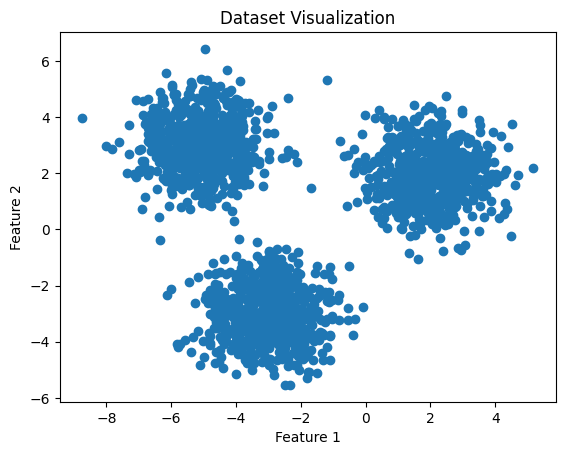

In [5]:
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Visualization")
plt.show()


- Instruction
    - Assume k = 3. Take the data points with indices 200, 800 and 1200 in X to be the initial cluster centers.

In [7]:
k = 3
cluster_centers = X[[200, 800, 1200]]

print(cluster_centers)
print(cluster_centers.shape)

[[ 1.40134606  0.88410301]
 [-2.56922887 -3.14989159]
 [-2.84782302 -3.37412632]]
(3, 2)


Question 4 -> Write a function assign_clusters(X, k, cluster_centers) that assigns a cluster to each data point as per their distance from each cluster centre and returns a vector z, where  z[i]∈{0,1,2} .

What is the mean of the values in vector z? Provide the answer correct up to three decimal places.

In [8]:
def assign_clusters(X, k, cluster_centers):
    z = np.zeros(X.shape[0], dtype=int)
    
    for i in range(X.shape[0]):
        distances = np.sum((X[i] - cluster_centers)**2, axis=1)
        z[i] = np.argmin(distances)
    
    return z

z = assign_clusters(X, 3, cluster_centers)

mean_z = np.mean(z)

print(round(mean_z, 3))

0.711


Question 5 -> Plot the data points, with different color for different clusters.

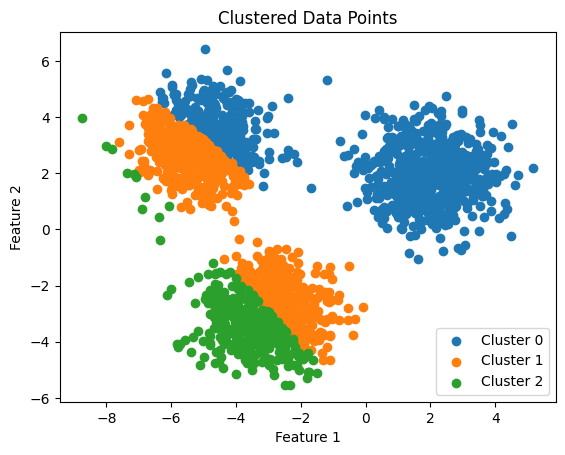

In [9]:
plt.scatter(X[z == 0, 0], X[z == 0, 1], label="Cluster 0")
plt.scatter(X[z == 1, 0], X[z == 1, 1], label="Cluster 1")
plt.scatter(X[z == 2, 0], X[z == 2, 1], label="Cluster 2")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clustered Data Points")
plt.legend()
plt.show()

Question 6 -> Write a function compute_cluster_centers(X, z, k) that computes the clusters' centers as per z and returns k new cluster centers.

What is the mean of the three cluster centers? Provide the  x1  and  y1  component. Provide both components correct up to three decimal places.

In [10]:
def compute_cluster_centers(X, z, k):
    centers = np.zeros((k, X.shape[1]))
    
    for j in range(k):
        centers[j] = np.mean(X[z == j], axis=0)
    
    return centers

cluster_centers = compute_cluster_centers(X, z, 3)

mean_centers = np.mean(cluster_centers, axis=0)

print(round(mean_centers[0], 3), round(mean_centers[1], 3))

-2.553 -0.192
